In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [3]:
# cykl 2017-2018
demo = pd.read_sas(r"DEMO_J.xpt", format="xport") #dane demograficzne
bmx = pd.read_sas(r"BMX_J.xpt", format="xport") #BMI
bpx = pd.read_sas(r"BPQ_J.xpt", format="xport") #cisnienie
alc = pd.read_sas(r"ALQ_J.xpt", format="xport")  # alkohol
diq = pd.read_sas(r"DIQ_J.xpt", format="xport") #czy zdiagnozowany na cukrzyce 
dpq = pd.read_sas(r"DPQ_J.xpt", format="xport") #DEPRESJA
fsq = pd.read_sas(r"FSQ_J.xpt", format="xport") #bezpieczeństwo żywnościowe
mcq = pd.read_sas(r"MCQ_J.xpt", format="xport") #stany chorobowe
paq = pd.read_sas(r"PAQ_J.xpt", format="xport") #aktywność fizyczna
slq = pd.read_sas(r"SLQ_J.xpt", format="xport") #zaburzenia snu
smq = pd.read_sas(r"SMQ_J.xpt", format="xport") # papierosy

#połączenie – rozszerzony zbiór cech 
df = demo.merge(bmx, on="SEQN")
df = df.merge(bpx, on="SEQN")
df = df.merge(alc, on="SEQN")
df = df.merge(diq, on="SEQN")
df = df.merge(dpq, on="SEQN")
df = df.merge(fsq, on="SEQN")
df = df.merge(mcq, on="SEQN")
df = df.merge(paq, on="SEQN")
df = df.merge(slq, on="SEQN")
df = df.merge(smq, on="SEQN")

print(f"Rekordów df1: {len(df)}")

Rekordów df1: 5533


In [4]:
def prepare_classification_dataset(df):
    data = df.copy()

    dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
    for col in dpq_cols:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan)
            
    data = data.dropna(subset=dpq_cols)
    data['PHQ9_score'] = data[dpq_cols].sum(axis=1)
    
    data['depression'] = (data['PHQ9_score'] >= 10).astype(int)
    
    features_demo = ['RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR']
    features_lifestyle = ['BMXBMI', 'SLD010H', 'ALQ130', 'SMQ020', 'PAQ605', 'PAQ650', 'FSD032A', 'FSD032B']
    features_diseases = ['DIQ010', 'BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L']
    
    all_features = features_demo + features_lifestyle + features_diseases
    available_cols = [col for col in all_features if col in data.columns]

    data = data[available_cols + ['depression']].copy()
    #czyszczenie braków (błędnych odpowiedzi)
    binary_cols = ['BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L', 'PAQ605', 'PAQ650', 'SMQ020']
    for col in binary_cols:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan).replace(2, 0)
            
    for col in ['FSD032A', 'FSD032B', 'DMDEDUC2']:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan)
            
    data['DIQ010'] = data['DIQ010'].replace([7, 9], np.nan).replace([2, 3], 0)   
    data['DMDMARTL'] = data['DMDMARTL'].replace([77, 99], np.nan)
    data['ALQ130'] = data['ALQ130'].replace([777, 999], np.nan)
        
    return data

data_class = prepare_classification_dataset(df)

print(f"Ilość pacjentów: {data_class.shape[0]}")
print(f"Przypadki depresji: {data_class['depression'].sum()} ({data_class['depression'].mean()*100:.1f}%)")

Ilość pacjentów: 5068
Przypadki depresji: 459 (9.1%)


# Trenowanie modeli

In [18]:
from sklearn.impute import KNNImputer
X1 = data_class.drop(columns=["depression"])
y1 = data_class["depression"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1)

imputer = KNNImputer(n_neighbors=5) 
X_train_imp = pd.DataFrame(imputer.fit_transform(X1_train), columns=X1_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X1_test), columns=X1_test.columns)

scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X_train_imp)
X1_test_sc  = scaler1.transform(X_test_imp)

lr1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr1.fit(X1_train_sc, y1_train)

y1_pred = lr1.predict(X1_test_sc)
y1_prob = lr1.predict_proba(X1_test_sc)[:, 1]

In [41]:
y1_test.shape

(1014,)

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X1_train_sm, y1_train_sm = smote.fit_resample(X_train_imp, y1_train)

lgbm = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, max_depth=-1, random_state=RANDOM_STATE, verbosity=-1)
lgbm.fit(X1_train_sm, y1_train_sm)

y_lgbm_pred = lgbm.predict(X1_test)
y_lgbm_prob = lgbm.predict_proba(X1_test)[:, 1]


In [6]:
X1_train_xgsm, y1_train_xgsm = smote.fit_resample(X_train_imp, y1_train)

xgboost = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100,learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=RANDOM_STATE)
xgboost.fit(X1_train_xgsm, y1_train_xgsm)

y_xgb_pred = xgboost.predict(X1_test)
y_xgb_prob = xgboost.predict_proba(X1_test)[:, 1]

In [7]:
catboost = CatBoostClassifier(
    iterations=500,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=False
)
catboost.fit(X1_train_sm, y1_train_sm)

y_cb_pred = catboost.predict(X1_test)
y_cb_prob = catboost.predict_proba(X1_test)[:, 1]

In [19]:
#bez usuwania Nan - imputer
models = [
    ("Logistic Regression",  y1_test, y1_pred, y1_prob),
    ("LightGBM",         y1_test, y_lgbm_pred, y_lgbm_prob),
    ("XGBoost",          y1_test, y_xgb_pred, y_xgb_prob),
    ("Catboost",         y1_test, y_cb_pred, y_cb_prob),
]

rows = []
for name, yt, yp, ypr in models:
    rep = classification_report(yt, yp, output_dict=True)
    rows.append({
        "Model"        : name,
        "Accuracy"     : round(accuracy_score(yt, yp), 4),
        "ROC AUC"      : round(roc_auc_score(yt, ypr), 4),
        "Avg Precision": round(average_precision_score(yt, ypr), 4),
        "F1 (macro)"   : round(f1_score(yt, yp, average='macro'), 4),
        "Precision (1)": round(rep['1']['precision'], 4),
        "Recall (1)"   : round(rep['1']['recall'], 4),
        "F1 (1)"       : round(rep['1']['f1-score'], 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

                     Accuracy  ROC AUC  Avg Precision  F1 (macro)  Precision (1)  Recall (1)  F1 (1)
Model                                                                                               
Logistic Regression    0.7278   0.7677         0.2715      0.5686         0.1993      0.6630  0.3065
LightGBM               0.9053   0.7510         0.2351      0.5306         0.3750      0.0652  0.1111
XGBoost                0.9083   0.7355         0.2411      0.5155         0.4444      0.0435  0.0792
Catboost               0.9103   0.7300         0.2540      0.5511         0.5333      0.0870  0.1495


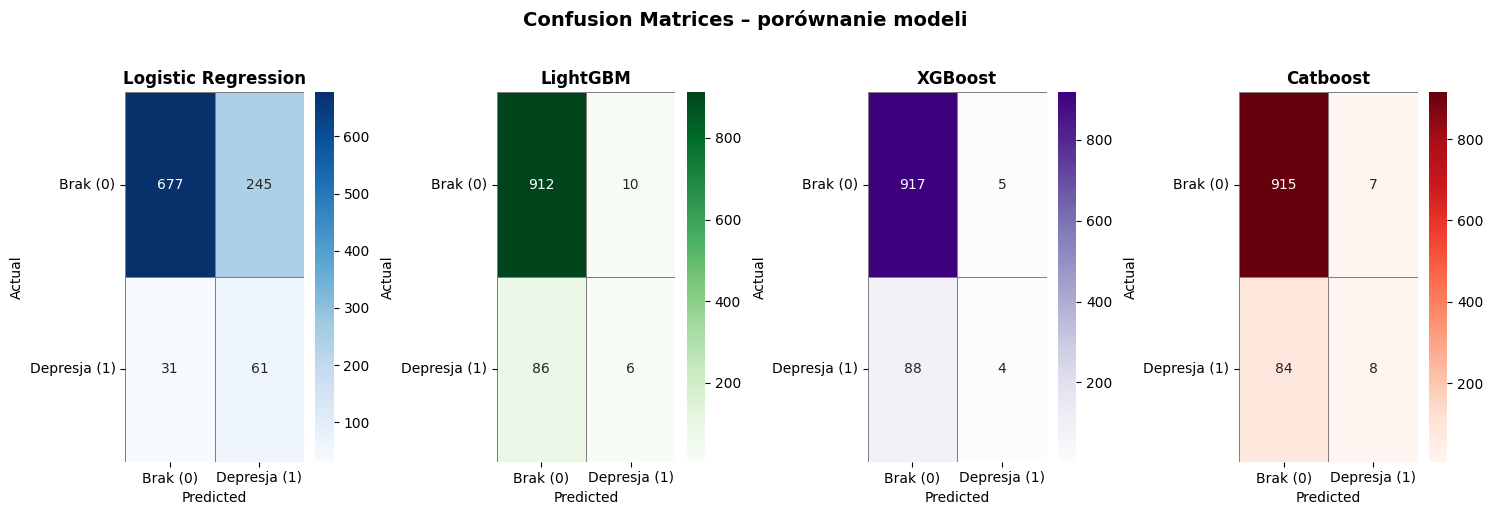

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
cmaps = ['Blues', 'Greens', 'Purples', 'Reds']

for ax, (name, yt, yp, _), cmap in zip(axes, models, cmaps):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, linewidths=0.5, linecolor='grey')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Brak (0)', 'Depresja (1)'])
    ax.set_yticklabels(['Brak (0)', 'Depresja (1)'], rotation=0)

fig.suptitle('Confusion Matrices – porównanie modeli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## WIelochorobowość

In [6]:
from functools import reduce

demo = pd.read_sas("DEMO_J.xpt")[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR']] #dane demograficzne
fsq = pd.read_sas("FSQ_J.xpt")[['SEQN', 'FSD032A', 'FSD032B']] #żywienie
hoq = pd.read_sas("HOQ_J.xpt")[['SEQN', 'HOQ065']] #stan mieszkaniowy
hiq = pd.read_sas("HIQ_J.xpt")[['SEQN', 'HIQ011']] #ubezpieczenie zdrowotne
smq = pd.read_sas("SMQ_J.xpt")[['SEQN', 'SMQ020']] #papierosy
smq_fam = pd.read_sas("SMQFAM_J.xpt")[['SEQN', 'SMD460']] #palenie w rodzinie
alq = pd.read_sas("ALQ_J.xpt")[['SEQN', 'ALQ130']] #alkohol
duq = pd.read_sas("DUQ_J.xpt")[['SEQN', 'DUQ240']] #narkotyki
bmx = pd.read_sas("BMX_J.xpt")[['SEQN', 'BMXBMI']] #BMI
cbc = pd.read_sas("CBC_J.xpt")[['SEQN', 'LBXHGB']] #hemoglobina
bpx_exam = pd.read_sas("BPX_J.xpt")[['SEQN', 'BPXSY1', 'BPXDI1']] #ciśnienie
glu = pd.read_sas("GLU_J.xpt")[['SEQN', 'LBXGLU']] #glukoza na czczo

dr1 = pd.read_sas("DR1TOT_J.xpt")[['SEQN', 'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12']]

#depresja
dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
dpq = pd.read_sas("DPQ_J.xpt")[['SEQN'] + dpq_cols]

diq = pd.read_sas("DIQ_J.xpt")[['SEQN', 'DIQ010']] #cukrzyca
bpq = pd.read_sas("BPQ_J.xpt")[['SEQN', 'BPQ020']] #nadciśnienie 
mcq = pd.read_sas("MCQ_J.xpt")[['SEQN', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']]

#łączenie danych
dfs = [demo, fsq, hoq, hiq, smq, smq_fam, alq, duq, bmx, cbc, bpx_exam, glu, dr1, dpq, diq, bpq, mcq]
df = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dfs)

#wybranie osobników z wielochorobowością - minimum 2 choroby
disease_cols = ['DIQ010', 'BPQ020', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']

for col in disease_cols:
    df[col] = df[col].replace([7, 9], 0) 
    df[col] = df[col].apply(lambda x: 1 if x == 1 else 0)

df['disease_count'] = df[disease_cols].sum(axis=1)
df = df[df['disease_count'] >= 2].copy()

#wyliczenie depresji 
for col in dpq_cols:
    df[col] = df[col].replace([7, 9], np.nan)
df = df.dropna(subset=dpq_cols) 
df['depression'] = (df[dpq_cols].sum(axis=1) >= 10).astype(int)

#czyszczenie braków
for col in ['HOQ065', 'HIQ011']:
    df[col] = df[col].replace([7, 9], np.nan)

#0 - nieubezpieczony zamiast 2
df['HIQ011'] = df['HIQ011'].replace(2, 0)

binary_features = ['SMQ020', 'SMD460', 'DUQ240']
for col in binary_features:
    df[col] = df[col].replace([7, 9], np.nan).replace(2, 0) 

df['FSD032A'] = df['FSD032A'].replace([7, 9], np.nan)
df['FSD032B'] = df['FSD032B'].replace([7, 9], np.nan)
df['DMDEDUC2'] = df['DMDEDUC2'].replace([7, 9], np.nan)
df['DMDMARTL'] = df['DMDMARTL'].replace([77, 99], np.nan)
df['ALQ130'] = df['ALQ130'].replace([777, 999], np.nan)

final_features = [
    'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR', #demografia
    'HOQ065', 'HIQ011', #mieszkanie i ubezpieczenie
    'FSD032A', 'FSD032B', #żywność
    'SMQ020', 'ALQ130', 'DUQ240', 'SMD460', #używki
    'BMXBMI', 'LBXHGB', #krew
    'BPXSY1', 'BPXDI1', 'LBXGLU', #ciśnienie skurczowe, rozkurczowe i glukoza
    'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12' #dieta
]

data_model = df[final_features + ['depression']].copy()

data_model.shape

(389, 23)

--- Wyniki Regresji Logistycznej ---
              precision    recall  f1-score   support

           0       0.88      0.67      0.76        64
           1       0.28      0.57      0.37        14

    accuracy                           0.65        78
   macro avg       0.58      0.62      0.57        78
weighted avg       0.77      0.65      0.69        78

ROC-AUC: 0.5871


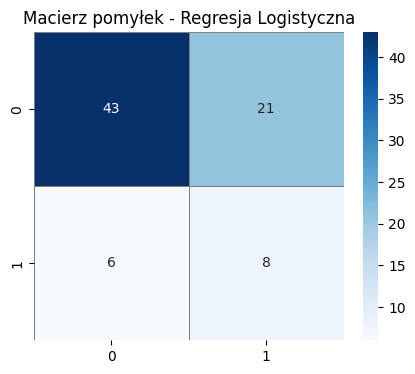

In [32]:
X = data_model.drop(columns=['depression'])
y = data_model['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = KNNImputer(n_neighbors=4) 
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
print("--- Wyniki Regresji Logistycznej ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()

In [33]:
import optuna

def objective(trial):
    c_val = trial.suggest_float("C", 1e-4, 10.0, log=True)
    penalty_val = trial.suggest_categorical("penalty", ["l2", None]) 

    lr = LogisticRegression(
        C=c_val,
        penalty=penalty_val,
        class_weight='balanced',
        max_iter=2000,
        solver='lbfgs',
        random_state=42
    )
    lr.fit(X_train_scaled, y_train)

    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(f"Najlepsze AUC: {study.best_value:.4f}")
print(f"Najlepsze parametry: {study.best_params}")

best_lr = LogisticRegression(
    **study.best_params, 
    class_weight='balanced', 
    max_iter=2000, 
    random_state=42
)
best_lr.fit(X_train_scaled, y_train)

[I 2026-05-27 13:07:49,264] A new study created in memory with name: no-name-a1df79da-9c8d-49dc-8272-cc5490dbeba4
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:07:49,293] Trial 0 finished with value: 0.5859375 and parameters: {'C': 0.312722380691724, 'penalty': None}. Best is trial 0 with value: 0.5859375.
[I 2026-05-27 13:07:49,296] Trial 1 finished with value: 0.6450892857142856 and parameters: {'C': 0.0017608820780200783, 'penalty': 'l2'}. Best is trial 1 with value: 0.6450892857142856.
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:07:49,321] Trial 2 finished with value: 0.5859375 and parameters: {'C': 0.00012124785288209439, 'penalty': None}. Best is trial 1 with value: 0.6450892857142856.
C

C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:07:50,009] Trial 37 finished with value: 0.5859375 and parameters: {'C': 0.0006932077613304901, 'penalty': None}. Best is trial 9 with value: 0.6517857142857142.
[I 2026-05-27 13:07:50,029] Trial 38 finished with value: 0.6450892857142856 and parameters: {'C': 0.0017159717095496375, 'penalty': 'l2'}. Best is trial 9 with value: 0.6517857142857142.
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:07:50,052] Trial 39 finished with value: 0.5859375 and parameters: {'C': 0.00017924792248635456, 'penalty': None}. Best is trial 9 with value: 0.6517857142857142.
[I 2026-05-27 13:07:50,071] Trial 40 finished with value: 0.6350446428571428 and parameters: {'C': 

Najlepsze AUC: 0.6518
Najlepsze parametry: {'C': 0.00014159972168626046, 'penalty': 'l2'}


LogisticRegression(C=0.00014159972168626046, class_weight='balanced',
                   max_iter=2000, random_state=42)

--- Wyniki Regresji Logistycznej ---
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        64
           1       0.25      0.64      0.36        14

    accuracy                           0.59        78
   macro avg       0.57      0.61      0.53        78
weighted avg       0.77      0.59      0.64        78

ROC-AUC: 0.5871


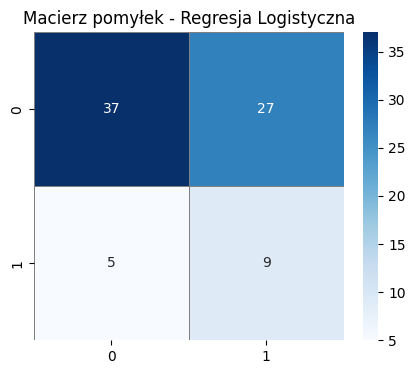

In [34]:
y_pred = best_lr.predict(X_test_scaled)
print("--- Wyniki Regresji Logistycznej ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()

In [37]:
#podział na cechy kategoryczne i liczbowe
cat_features = ['RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'HOQ065', 
                'HIQ011', 'FSD032A', 'FSD032B', 'SMQ020', 'SMD460', 'DUQ240']

for col in cat_features:
    data_model[col] = data_model[col].astype(str)

X = data_model.drop(columns=['depression'])
y = data_model['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
def objective_balanced(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',            
        'cat_features': cat_features,
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    return auc

study_balanced = optuna.create_study(direction='maximize') 
study_balanced.optimize(objective_balanced, n_trials=40)  

print(f"Najlepsze parametry: {study_balanced.best_params}")
print(f"Najlepsze AUC: {study_balanced.best_value}")

best_model_balanced = CatBoostClassifier(**study_balanced.best_params, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)
best_model_balanced.fit(X_train, y_train)

print(classification_report(y_test, best_model_balanced.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_balanced.predict_proba(X_test)[:, 1]):.4f}")

[I 2026-05-09 12:39:40,086] A new study created in memory with name: no-name-441ccc85-f676-4ecb-b2f7-693b3ee68af1
[I 2026-05-09 12:39:43,210] Trial 0 finished with value: 0.6272321428571428 and parameters: {'iterations': 316, 'learning_rate': 0.01504548344866413, 'depth': 8, 'l2_leaf_reg': 7.207376003820658}. Best is trial 0 with value: 0.6272321428571428.
[I 2026-05-09 12:39:45,567] Trial 1 finished with value: 0.6595982142857143 and parameters: {'iterations': 208, 'learning_rate': 0.04906394639240648, 'depth': 6, 'l2_leaf_reg': 5.064982946635423}. Best is trial 1 with value: 0.6595982142857143.
[I 2026-05-09 12:39:48,103] Trial 2 finished with value: 0.6529017857142858 and parameters: {'iterations': 377, 'learning_rate': 0.08634994136090376, 'depth': 6, 'l2_leaf_reg': 4.168104245696437}. Best is trial 1 with value: 0.6595982142857143.
[I 2026-05-09 12:39:50,618] Trial 3 finished with value: 0.6651785714285714 and parameters: {'iterations': 137, 'learning_rate': 0.05195261426852932, '

[I 2026-05-09 12:41:23,381] Trial 33 finished with value: 0.7087053571428572 and parameters: {'iterations': 128, 'learning_rate': 0.1041719243726995, 'depth': 6, 'l2_leaf_reg': 8.402145013257794}. Best is trial 9 with value: 0.7310267857142857.
[I 2026-05-09 12:41:29,350] Trial 34 finished with value: 0.6941964285714286 and parameters: {'iterations': 204, 'learning_rate': 0.1521997084384384, 'depth': 8, 'l2_leaf_reg': 6.620678871012182}. Best is trial 9 with value: 0.7310267857142857.
[I 2026-05-09 12:41:30,817] Trial 35 finished with value: 0.7064732142857143 and parameters: {'iterations': 156, 'learning_rate': 0.025568902481237832, 'depth': 6, 'l2_leaf_reg': 4.937812503251582}. Best is trial 9 with value: 0.7310267857142857.
[I 2026-05-09 12:41:32,991] Trial 36 finished with value: 0.6930803571428571 and parameters: {'iterations': 114, 'learning_rate': 0.08639459410476831, 'depth': 7, 'l2_leaf_reg': 7.362487799437055}. Best is trial 9 with value: 0.7310267857142857.
[I 2026-05-09 12:

Najlepsze parametry: {'iterations': 150, 'learning_rate': 0.025056497338739107, 'depth': 6, 'l2_leaf_reg': 2.2867604965114174}
Najlepsze AUC: 0.7310267857142857
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        64
           1       0.21      0.29      0.24        14

    accuracy                           0.68        78
   macro avg       0.52      0.53      0.52        78
weighted avg       0.72      0.68      0.70        78

ROC-AUC: 0.6217


<Axes: >

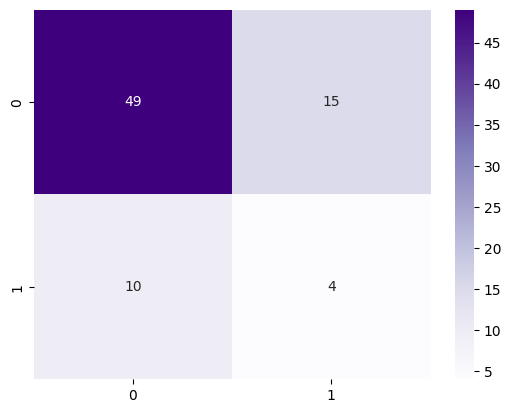

In [56]:
cm = confusion_matrix(y_test, best_model_balanced.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")


### Ze SMOTE 

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

X = data_model.drop(columns=['depression']).astype(float)
y = data_model['depression'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='most_frequent') 
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print(f"NaN przed SMOTE: {X_train_imp.isna().sum().sum()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

print(f"Liczność klas po SMOTE:\n{y_train_smote.value_counts()}")

NaN przed SMOTE: 0
Liczność klas po SMOTE:
depression
0    253
1    253
Name: count, dtype: int64


In [44]:
def objective_smote(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train_smote, y_train_smote, eval_set=[(X_test_imp, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test_imp)[:, 1]
    return roc_auc_score(y_test, preds_proba)

study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=40)

print(f"Najlepsze parametry: {study_smote.best_params}")
print(f"Najlepsze AUC: {study_smote.best_value}")

best_model_smote = CatBoostClassifier(**study_smote.best_params, verbose=False)
best_model_smote.fit(X_train_smote, y_train_smote)

print(classification_report(y_test, best_model_smote.predict(X_test_imp)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_smote.predict_proba(X_test_imp)[:, 1]):.4f}")

[I 2026-05-09 12:46:23,650] A new study created in memory with name: no-name-28164d45-1341-4024-848f-9c029c1962ec
[I 2026-05-09 12:46:23,837] Trial 0 finished with value: 0.6110491071428572 and parameters: {'iterations': 361, 'learning_rate': 0.01892424527259533, 'depth': 6, 'l2_leaf_reg': 7.558394402203422}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:23,962] Trial 1 finished with value: 0.5457589285714286 and parameters: {'iterations': 104, 'learning_rate': 0.12637138588106003, 'depth': 4, 'l2_leaf_reg': 4.150616266218643}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:24,153] Trial 2 finished with value: 0.5457589285714286 and parameters: {'iterations': 389, 'learning_rate': 0.16920015537825345, 'depth': 4, 'l2_leaf_reg': 9.550407074782111}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:24,342] Trial 3 finished with value: 0.62109375 and parameters: {'iterations': 478, 'learning_rate': 0.02405183043198923, 'depth': 

[I 2026-05-09 12:46:33,158] Trial 34 finished with value: 0.6897321428571429 and parameters: {'iterations': 251, 'learning_rate': 0.022164105815751026, 'depth': 8, 'l2_leaf_reg': 9.430553745760076}. Best is trial 28 with value: 0.6908482142857143.
[I 2026-05-09 12:46:33,542] Trial 35 finished with value: 0.6897321428571429 and parameters: {'iterations': 242, 'learning_rate': 0.04125987627981641, 'depth': 8, 'l2_leaf_reg': 9.406069907579454}. Best is trial 28 with value: 0.6908482142857143.
[I 2026-05-09 12:46:33,914] Trial 36 finished with value: 0.6897321428571429 and parameters: {'iterations': 208, 'learning_rate': 0.023388904026056142, 'depth': 8, 'l2_leaf_reg': 9.523410389534924}. Best is trial 28 with value: 0.6908482142857143.
[I 2026-05-09 12:46:34,312] Trial 37 finished with value: 0.6032366071428572 and parameters: {'iterations': 175, 'learning_rate': 0.04769093234243107, 'depth': 8, 'l2_leaf_reg': 7.9583642268741395}. Best is trial 28 with value: 0.6908482142857143.
[I 2026-0

Najlepsze parametry: {'iterations': 324, 'learning_rate': 0.02146667435548067, 'depth': 8, 'l2_leaf_reg': 8.439491603030902}
Najlepsze AUC: 0.6908482142857143
              precision    recall  f1-score   support

           0       0.80      0.81      0.81        64
           1       0.08      0.07      0.07        14

    accuracy                           0.68        78
   macro avg       0.44      0.44      0.44        78
weighted avg       0.67      0.68      0.67        78

ROC-AUC: 0.5647


<Axes: >

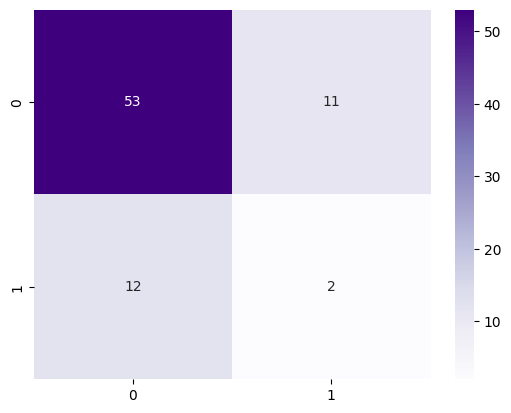

In [54]:
cm = confusion_matrix(y_test, best_model_smote.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")

--- Wyniki Regresji Logistycznej (Wielochorobowość) ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        64
           1       0.23      0.43      0.30        14

    accuracy                           0.64        78
   macro avg       0.54      0.56      0.53        78
weighted avg       0.74      0.64      0.68        78

ROC-AUC: 0.5223


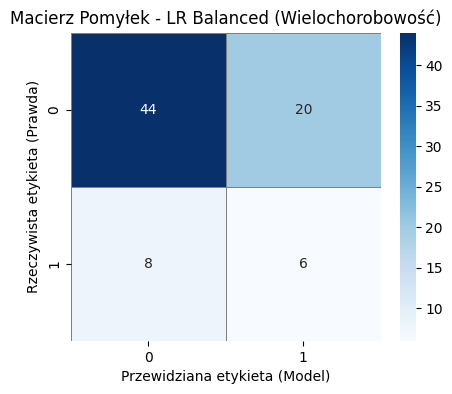

In [27]:
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_imp)
X_test_lr = scaler.transform(X_test_imp)

lr_multi = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_multi.fit(X_train_lr, y_train)

y_pred_lr = lr_multi.predict(X_test_lr)
y_prob_lr = lr_multi.predict_proba(X_test_lr)[:, 1]

print("--- Wyniki Regresji Logistycznej (Wielochorobowość) ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz Pomyłek - LR Balanced (Wielochorobowość)')
plt.xlabel('Przewidziana etykieta (Model)')
plt.ylabel('Rzeczywista etykieta (Prawda)')
plt.show()

In [35]:
def objective(trial):
    c_val = trial.suggest_float("C", 1e-4, 10.0, log=True)
    penalty_val = trial.suggest_categorical("penalty", ["l2", None])
    
    lr = LogisticRegression(
        C=c_val,
        penalty=penalty_val,
        class_weight='balanced',
        max_iter=2000,
        solver='lbfgs',
        random_state=42
    )
    lr.fit(X_train_lr, y_train)
    y_prob = lr.predict_proba(X_test_lr)[:, 1]
    return roc_auc_score(y_test, y_prob)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print(f"Najlepsze AUC: {study.best_value:.4f}")
print(f"Najlepsze parametry: {study.best_params}")

lr_multi = LogisticRegression(
    **study.best_params,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
lr_multi.fit(X_train_lr, y_train)

[I 2026-05-27 13:10:40,931] A new study created in memory with name: no-name-3784da23-3f4e-4ee7-abda-e31c3b6785ea
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:10:40,949] Trial 0 finished with value: 0.5212053571428572 and parameters: {'C': 0.002705397255880406, 'penalty': None}. Best is trial 0 with value: 0.5212053571428572.
[I 2026-05-27 13:10:40,963] Trial 1 finished with value: 0.5223214285714286 and parameters: {'C': 7.914143228623322, 'penalty': 'l2'}. Best is trial 1 with value: 0.5223214285714286.
[I 2026-05-27 13:10:40,976] Trial 2 finished with value: 0.5223214285714286 and parameters: {'C': 7.489527446044063, 'penalty': 'l2'}. Best is trial 1 with value: 0.5223214285714286.
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio paramete

C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:10:41,616] Trial 37 finished with value: 0.5212053571428572 and parameters: {'C': 0.010874757110244574, 'penalty': None}. Best is trial 13 with value: 0.5602678571428571.
[I 2026-05-27 13:10:41,633] Trial 38 finished with value: 0.5513392857142858 and parameters: {'C': 0.0015146102837410875, 'penalty': 'l2'}. Best is trial 13 with value: 0.5602678571428571.
[I 2026-05-27 13:10:41,642] Trial 39 finished with value: 0.5591517857142857 and parameters: {'C': 0.00028112448271684084, 'penalty': 'l2'}. Best is trial 13 with value: 0.5602678571428571.
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
[I 2026-05-27 13:10:41,657] Trial 40 finished with value: 0.5212053571428572 an

Najlepsze AUC: 0.5603
Najlepsze parametry: {'C': 0.0007678168704263724, 'penalty': 'l2'}


LogisticRegression(C=0.0007678168704263724, class_weight='balanced',
                   max_iter=2000, random_state=42)

--- Wyniki Regresji Logistycznej ---
              precision    recall  f1-score   support

           0       0.86      0.58      0.69        64
           1       0.23      0.57      0.33        14

    accuracy                           0.58        78
   macro avg       0.54      0.57      0.51        78
weighted avg       0.75      0.58      0.63        78

ROC-AUC: 0.5871


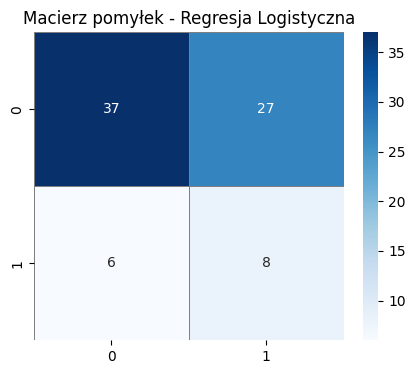

In [36]:
y_pred = lr_multi.predict(X_test_scaled)
print("--- Wyniki Regresji Logistycznej ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()

### Bez multichorobowości

In [18]:
demo = pd.read_sas("DEMO_J.xpt")[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR']] #dane demograficzne
fsq = pd.read_sas("FSQ_J.xpt")[['SEQN', 'FSD032A', 'FSD032B']] #żywienie
hoq = pd.read_sas("HOQ_J.xpt")[['SEQN', 'HOQ065']] #stan mieszkaniowy
hiq = pd.read_sas("HIQ_J.xpt")[['SEQN', 'HIQ011']] #ubezpieczenie zdrowotne
smq = pd.read_sas("SMQ_J.xpt")[['SEQN', 'SMQ020']] #papierosy
smq_fam = pd.read_sas("SMQFAM_J.xpt")[['SEQN', 'SMD460']] #palenie w rodzinie
alq = pd.read_sas("ALQ_J.xpt")[['SEQN', 'ALQ130']] #alkohol
duq = pd.read_sas("DUQ_J.xpt")[['SEQN', 'DUQ240']] #narkotyki
bmx = pd.read_sas("BMX_J.xpt")[['SEQN', 'BMXBMI']] #BMI
cbc = pd.read_sas("CBC_J.xpt")[['SEQN', 'LBXHGB']] #hemoglobina
bpx_exam = pd.read_sas("BPX_J.xpt")[['SEQN', 'BPXSY1', 'BPXDI1']] #ciśnienie
glu = pd.read_sas("GLU_J.xpt")[['SEQN', 'LBXGLU']] #glukoza na czczo

dr1 = pd.read_sas("DR1TOT_J.xpt")[['SEQN', 'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12']]

#depresja
dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
dpq = pd.read_sas("DPQ_J.xpt")[['SEQN'] + dpq_cols]

diq = pd.read_sas("DIQ_J.xpt")[['SEQN', 'DIQ010']]
bpq = pd.read_sas("BPQ_J.xpt")[['SEQN', 'BPQ020']] 
mcq = pd.read_sas("MCQ_J.xpt")[['SEQN', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']]

#łączenie danych
dfs = [demo, fsq, hoq, hiq, smq, smq_fam, alq, duq, bmx, cbc, bpx_exam, glu, dr1, dpq, diq, bpq, mcq]
df = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dfs)

disease_cols = ['DIQ010', 'BPQ020', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']

#wyliczenie depresji 
for col in dpq_cols:
    df[col] = df[col].replace([7, 9], np.nan)
df = df.dropna(subset=dpq_cols) 
df['depression'] = (df[dpq_cols].sum(axis=1) >= 10).astype(int)

#czyszczenie braków
for col in ['HOQ065', 'HIQ011']:
    df[col] = df[col].replace([7, 9], np.nan)
    
df['HIQ011'] = df['HIQ011'].replace(2, 0)

binary_features = ['SMQ020', 'DUQ240']
for col in binary_features:
    df[col] = df[col].replace([7, 9], np.nan).replace(2, 0) 

df['SMD460'] = np.round(df['SMD460'])
df['SMD460'] = df['SMD460'].replace([777, 999], np.nan)

df['FSD032A'] = df['FSD032A'].replace([7, 9], np.nan)
df['FSD032B'] = df['FSD032B'].replace([7, 9], np.nan)
df['DMDEDUC2'] = df['DMDEDUC2'].replace([7, 9], np.nan)
df['DMDMARTL'] = df['DMDMARTL'].replace([77, 99], np.nan)
df['ALQ130'] = df['ALQ130'].replace([777, 999], np.nan)

final_features = [
    'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR', #demografia
    'HOQ065', 'HIQ011', #mieszkanie i ubezpieczenie
    'FSD032A', 'FSD032B', #żywność
    'SMQ020', 'ALQ130', 'DUQ240', 'SMD460', #używki
    'BMXBMI', 'LBXHGB', #krew
    'BPXSY1', 'BPXDI1', 'LBXGLU', #ciśnienie skurczowe, rozkurczowe i glukoza
    'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12' #dieta
]

data_model2 = df[final_features + ['depression']].copy()

data_model2.shape

(2037, 23)

In [19]:
cat_features = ['RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'HOQ065', 
                'HIQ011', 'FSD032A', 'FSD032B', 'SMQ020', 'SMD460', 'DUQ240']

for col in cat_features:
    data_model2[col] = data_model2[col].astype(str)

X = data_model2.drop(columns=['depression'])
y = data_model2['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

[I 2026-05-09 12:56:05,692] A new study created in memory with name: no-name-7f494cc0-b8d1-40c1-b774-8d8c53d17c6f
[I 2026-05-09 12:56:08,524] Trial 0 finished with value: 0.755889097352512 and parameters: {'iterations': 432, 'learning_rate': 0.015790730139316783, 'depth': 7, 'l2_leaf_reg': 3.0480899593354205}. Best is trial 0 with value: 0.755889097352512.
[I 2026-05-09 12:56:11,019] Trial 1 finished with value: 0.7356681259120283 and parameters: {'iterations': 212, 'learning_rate': 0.024630230546771745, 'depth': 7, 'l2_leaf_reg': 5.311236334524952}. Best is trial 0 with value: 0.755889097352512.
[I 2026-05-09 12:56:13,628] Trial 2 finished with value: 0.7463692585643805 and parameters: {'iterations': 103, 'learning_rate': 0.026633531860802927, 'depth': 5, 'l2_leaf_reg': 6.88578241726724}. Best is trial 0 with value: 0.755889097352512.
[I 2026-05-09 12:56:15,559] Trial 3 finished with value: 0.7547772913626571 and parameters: {'iterations': 344, 'learning_rate': 0.08895513096019479, 'd

Najlepsze parametry: {'iterations': 371, 'learning_rate': 0.015006993166815707, 'depth': 7, 'l2_leaf_reg': 3.4605330010506634}
Najlepsze AUC: 0.767632548120353
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       369
           1       0.24      0.49      0.32        39

    accuracy                           0.81       408
   macro avg       0.59      0.66      0.61       408
weighted avg       0.87      0.81      0.83       408

ROC-AUC: 0.7165


<Axes: >

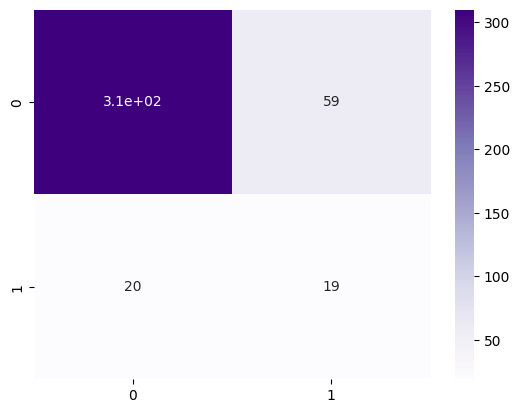

In [63]:
def objective_balanced(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',            
        'cat_features': cat_features,
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    return auc

study_cb = optuna.create_study(direction='maximize') 
study_cb.optimize(objective_balanced, n_trials=20)  

print(f"Najlepsze parametry: {study_cb.best_params}")
print(f"Najlepsze AUC: {study_cb.best_value}")

best_model_catb = CatBoostClassifier(**study_cb.best_params, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)
best_model_catb.fit(X_train, y_train)

print(classification_report(y_test, best_model_catb.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_catb.predict_proba(X_test)[:, 1]):.4f}")

cm = confusion_matrix(y_test, best_model_catb.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")

In [24]:
def objective_balanced(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',            
        'cat_features': cat_features,
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    return auc

study_cb = optuna.create_study(direction='maximize') 
study_cb.optimize(objective_balanced, n_trials=20)  

print(f"Najlepsze parametry: {study_cb.best_params}")
print(f"Najlepsze AUC: {study_cb.best_value}")

best_model_catb = CatBoostClassifier(**study_cb.best_params, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)
best_model_catb.fit(X_train, y_train)

print(classification_report(y_test, best_model_catb.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_catb.predict_proba(X_test)[:, 1]):.4f}")

cm = confusion_matrix(y_test, best_model_catb.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")

Najlepsze parametry: {'iterations': 342, 'learning_rate': 0.04533507200259816, 'depth': 3, 'l2_leaf_reg': 6.923933439641274}
Najlepsze AUC: 0.7729831144465291
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       369
           1       0.18      0.46      0.26        39

    accuracy                           0.74       408
   macro avg       0.55      0.62      0.55       408
weighted avg       0.86      0.74      0.79       408

ROC-AUC: 0.6604


<Axes: >

--- Wyniki Regresji Logistycznej ---
              precision    recall  f1-score   support

           0       0.93      0.69      0.79       369
           1       0.16      0.54      0.24        39

    accuracy                           0.68       408
   macro avg       0.54      0.61      0.52       408
weighted avg       0.86      0.68      0.74       408

ROC-AUC: 0.6852


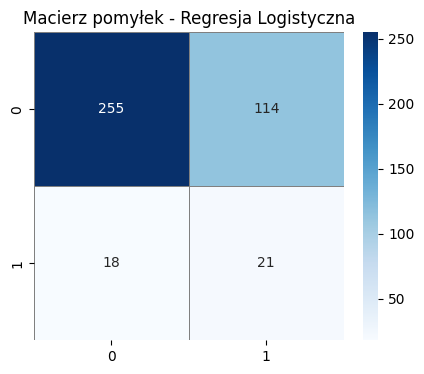

In [10]:
X = data_model2.drop(columns=['depression'])
y = data_model2['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = KNNImputer(n_neighbors=4) 
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
print("--- Wyniki Regresji Logistycznej ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz pomyłek - Regresja Logistyczna')
plt.show()

In [47]:
rep = classification_report(y_test, y_pred, output_dict=True)

print("Dokładność:", round(accuracy_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_pred), 4))
print("Precyzja:", round(rep['1']['precision'], 4)) 
print("Czułość:", round(rep['1']['recall'], 4))


Dokładność: 0.6765
AUC: 0.6148
Precyzja: 0.1556
Czułość: 0.5385


[I 2026-05-30 13:22:20,009] A new study created in memory with name: no-name-1b2a9d09-7917-45fd-b152-50f639b7356c
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\oliwi\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C

Najlepsze parametry Optuny: {'C': 0.00010343169165036108, 'penalty': 'l2'}
Najlepsze AUC z prób: 0.6971

--- Wyniki Ostatecznej Regresji Logistycznej ---
              precision    recall  f1-score   support

           0       0.94      0.69      0.79       369
           1       0.17      0.62      0.27        39

    accuracy                           0.68       408
   macro avg       0.56      0.65      0.53       408
weighted avg       0.87      0.68      0.74       408

Ostateczne ROC-AUC: 0.6971


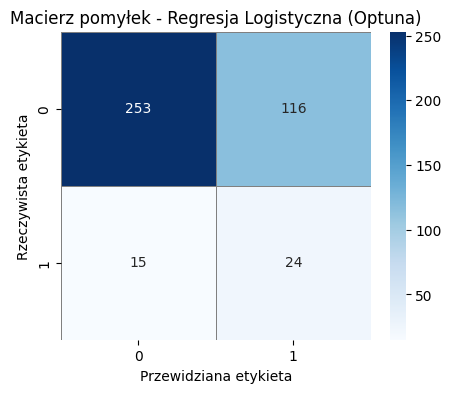

In [11]:
X = data_model2.drop(columns=['depression'])
y = data_model2['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = KNNImputer(n_neighbors=4) 
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

def objective(trial):
    c_val = trial.suggest_float("C", 1e-4, 10.0, log=True)
    penalty_val = trial.suggest_categorical("penalty", ["l2", None])
    lr = LogisticRegression(
        C=c_val,
        penalty=penalty_val,
        class_weight='balanced',
        max_iter=2000,
        solver='lbfgs',
        random_state=42
    )
    lr.fit(X_train_scaled, y_train)
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, y_prob)

study = optuna.create_study(direction="maximize")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study.optimize(objective, n_trials=50)

print(f"Najlepsze parametry Optuny: {study.best_params}")
print(f"Najlepsze AUC z prób: {study.best_value:.4f}\n")

lr_model = LogisticRegression(
    **study.best_params,
    class_weight='balanced', 
    max_iter=2000, 
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
y_prob_final = lr_model.predict_proba(X_test_scaled)[:, 1]
print("--- Wyniki Ostatecznej Regresji Logistycznej ---")
print(classification_report(y_test, y_pred))
print(f"Ostateczne ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='grey')
plt.title('Macierz pomyłek - Regresja Logistyczna (Optuna)')
plt.xlabel('Przewidziana etykieta')
plt.ylabel('Rzeczywista etykieta')
plt.show()